In [ ]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Dataset paths
PATH_1M  = 'data/customer_churn_1M.csv.gz'
PATH_IBM = 'data/Telco-Customer-Churn.csv'

# Output folders
FIGURE_PATH = 'figures/'
OUTPUT_PATH = 'outputs/'

os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from imblearn.combine import SMOTEENN

!pip install catboost pytorch-tabnet shap -q
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import shap
from scipy.stats import spearmanr

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EDA - 1M dataset

In [ ]:
# Load 1M dataset
df_1m_eda = pd.read_csv(PATH_1M, low_memory=False)
print('Shape:', df_1m_eda.shape)
df_1m_eda.head()

Shape: (1000000, 32)


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [ ]:
# 1M basic info
df_1m_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  object 
 1   signup_date                  1000000 non-null  object 
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  object 
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  object 
 6   marital_status               1000000 non-null  object 
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  object 
 10  payment_method               1000000 non-null  object 
 11  paperless_billing            1000000 non-null  object 
 12  senior_citizen               1000000 non-nu

In [ ]:
# 1M statistics
df_1m_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,44.724603,14.479468,18.0,34.00,44.00,55.00,90.000000
annual_income,970041.0,58788.311936,37137.433079,20000.0,32712.56,48954.60,73475.13,250000.000000
dependents,1000000.0,0.799831,0.893654,0.0,0.00,1.00,1.00,5.000000
tenure,1000000.0,22.381923,20.073341,1.0,6.00,16.00,33.00,72.000000
senior_citizen,1000000.0,0.199511,0.399633,0.0,0.00,0.00,0.00,1.000000
monthlycharges,1000000.0,86.443701,27.592430,20.0,70.49,85.48,100.68,854.956730
totalcharges,1000000.0,1837.321438,1803.721634,16.3,484.53,1249.75,2617.66,16252.861508
num_services,1000000.0,2.563721,1.412330,1.0,1.00,2.00,3.00,6.000000
has_phone_service,1000000.0,0.769551,0.421120,0.0,1.00,1.00,1.00,1.000000
has_internet_service,1000000.0,0.849742,0.357324,0.0,1.00,1.00,1.00,1.000000


churn
0    900773
1     99227
Name: count, dtype: int64
Churn rate: 9.92 %


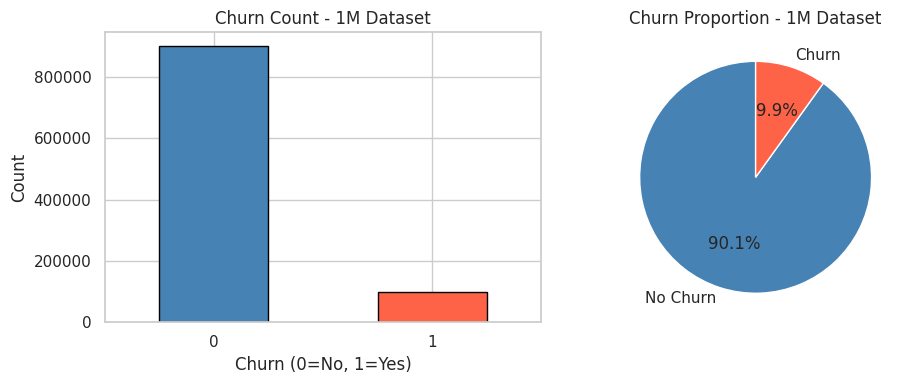

In [ ]:
# 1M churn distribution
# Check how many customers churned vs did not churn
print(df_1m_eda['churn'].value_counts())
print('Churn rate:', round(df_1m_eda['churn'].mean() * 100, 2), '%')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_1m_eda['churn'].value_counts().plot(kind='bar', ax=ax[0],
    color=['steelblue', 'tomato'], edgecolor='black')
ax[0].set_title('Churn Count - 1M Dataset')
ax[0].set_xlabel('Churn (0=No, 1=Yes)')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=0)

df_1m_eda['churn'].value_counts().plot(kind='pie', ax=ax[1],
    autopct='%1.1f%%', colors=['steelblue', 'tomato'],
    startangle=90, labels=['No Churn', 'Churn'])
ax[1].set_title('Churn Proportion - 1M Dataset')
ax[1].set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'churn_dist_1m.png', bbox_inches='tight')
plt.show()

In [ ]:
# 1M missing values
missing = df_1m_eda.isnull().sum()
missing_pct = (missing / len(df_1m_eda)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                       Missing Count  Missing (%)
avg_monthly_gb                 50012         5.00
credit_score                   40395         4.04
annual_income                  29959         3.00
num_complaints                 29906         2.99
customer_satisfaction          19921         1.99


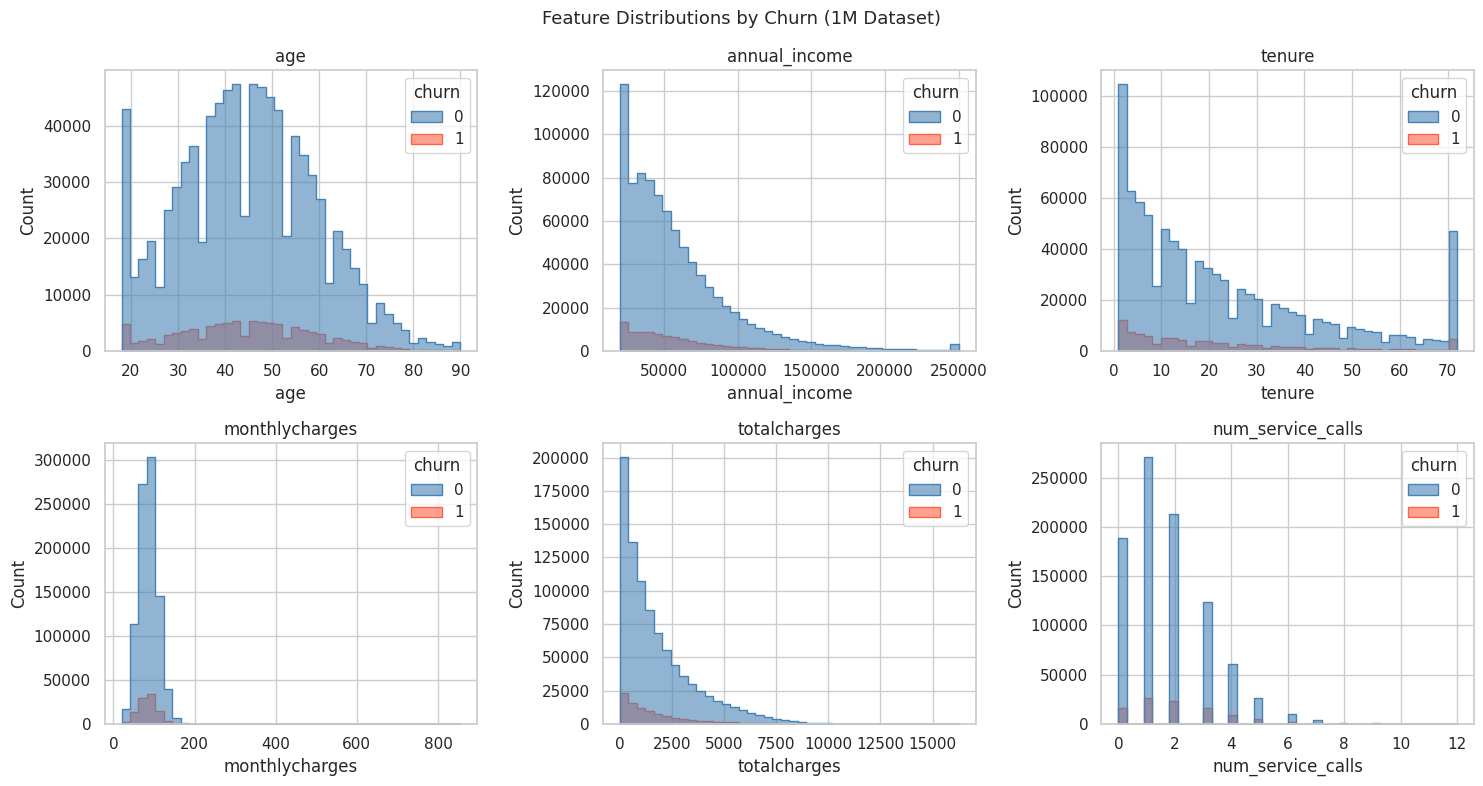

In [ ]:
# 1M feature distributions by churn
num_cols = df_1m_eda.select_dtypes(include=np.number).columns.tolist()
plot_cols = [c for c in num_cols if c != 'churn' and df_1m_eda[c].nunique() > 10][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_1m_eda, x=col, hue='churn', bins=40,
                 palette=['steelblue', 'tomato'], alpha=0.6,
                 element='step', ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('Feature Distributions by Churn (1M Dataset)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'feature_dist_1m.png', bbox_inches='tight')
plt.show()

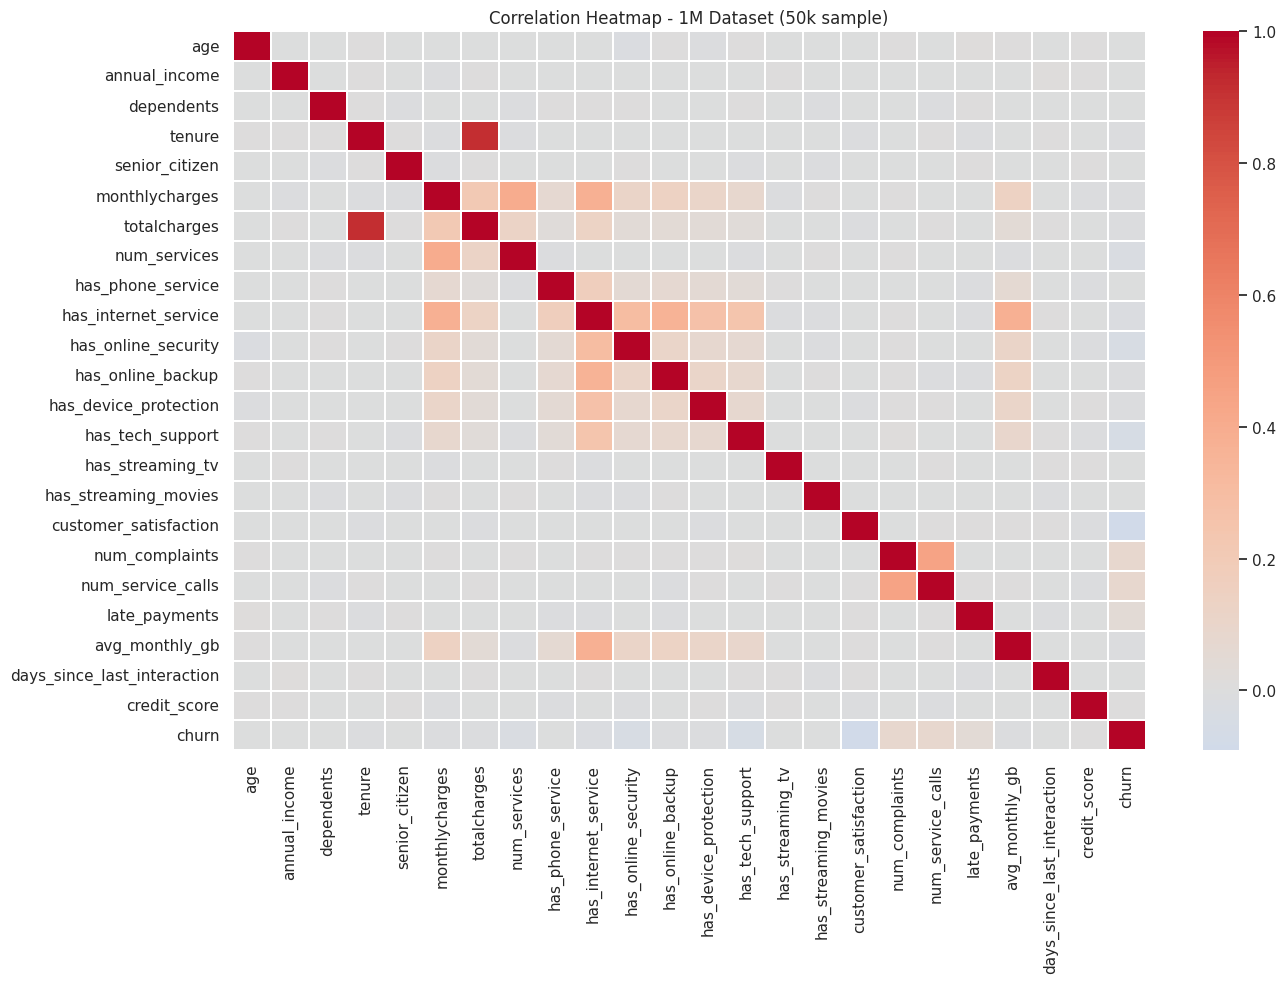

Top features correlated with churn:
customer_satisfaction   -0.090935
num_complaints           0.085803
num_service_calls        0.084519
has_tech_support        -0.049275
late_payments            0.046055
has_online_security     -0.037180
num_services            -0.025036
has_internet_service    -0.020453
monthlycharges          -0.013544
totalcharges            -0.013429
has_online_backup       -0.012214
tenure                  -0.009270
avg_monthly_gb          -0.008620
has_device_protection   -0.008267
credit_score             0.007857
Name: churn, dtype: float64


In [ ]:
# 1M Correlation heatmap
# Use a sample of 50k rows to speed up correlation calculation
sample = df_1m_eda.select_dtypes(include=np.number).sample(50000, random_state=42)
corr = sample.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap - 1M Dataset (50k sample)')
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'corr_heatmap_1m.png', bbox_inches='tight')
plt.show()

# Top features correlated with churn
print('Top features correlated with churn:')
print(corr['churn'].drop('churn').sort_values(key=abs, ascending=False).head(15))

EDA - IBM Telco dataset

In [ ]:
# Load IBM Telco
df_ibm_eda = pd.read_csv(PATH_IBM, low_memory=False)
print('Shape:', df_ibm_eda.shape)
df_ibm_eda.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


churn_binary
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.54 %


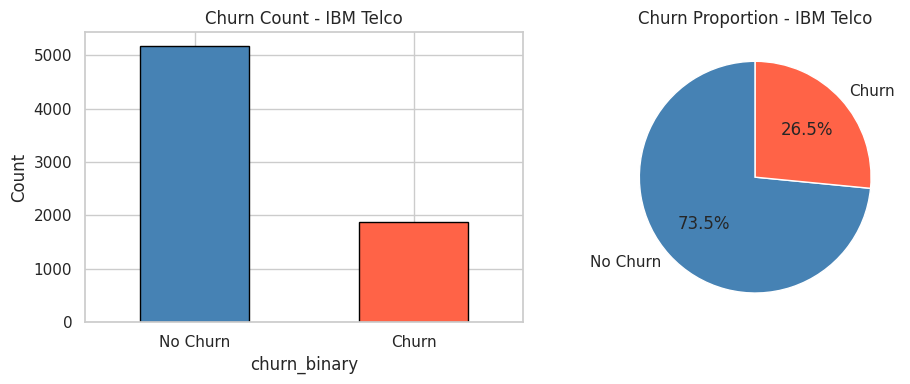

In [ ]:
# IBM Telco churn distribution
df_ibm_eda['churn_binary'] = (df_ibm_eda['Churn'] == 'Yes').astype(int)
print(df_ibm_eda['churn_binary'].value_counts())
print('Churn rate:', round(df_ibm_eda['churn_binary'].mean() * 100, 2), '%')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_ibm_eda['churn_binary'].value_counts().plot(kind='bar', ax=ax[0],
    color=['steelblue', 'tomato'], edgecolor='black')
ax[0].set_title('Churn Count - IBM Telco')
ax[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
ax[0].set_ylabel('Count')

df_ibm_eda['churn_binary'].value_counts().plot(kind='pie', ax=ax[1],
    autopct='%1.1f%%', colors=['steelblue', 'tomato'],
    startangle=90, labels=['No Churn', 'Churn'])
ax[1].set_title('Churn Proportion - IBM Telco')
ax[1].set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'churn_dist_ibm.png', bbox_inches='tight')
plt.show()

In [ ]:
# IBM Telco missing values
# Check missing values
missing_ibm = df_ibm_eda.isnull().sum()
print('Missing values:')
print(missing_ibm[missing_ibm > 0])

# Check blank spaces in Total Charges
blank = (df_ibm_eda['TotalCharges'].astype(str).str.strip() == '').sum()
print(f'\nBlank TotalCharges entries: {blank}')

Missing values:
Series([], dtype: int64)

Blank TotalCharges entries: 11


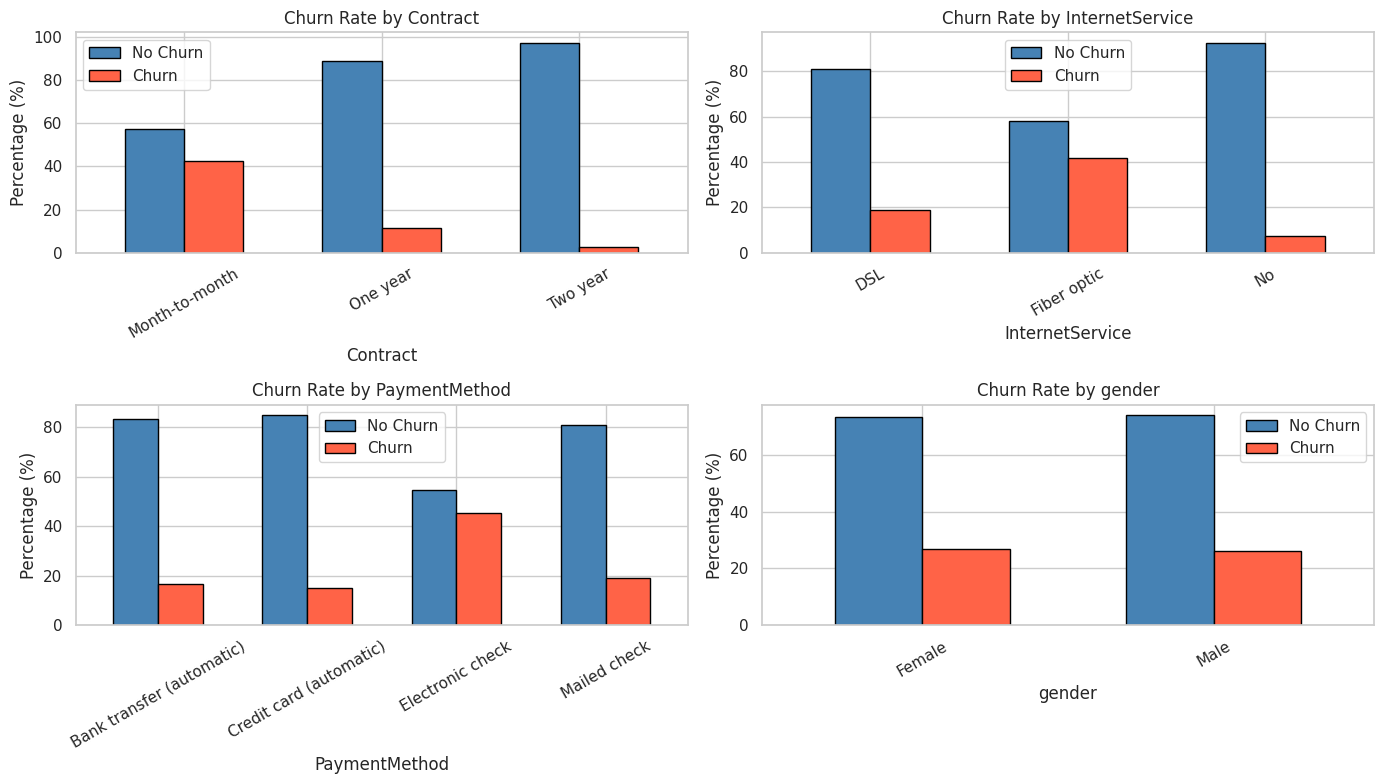

In [ ]:
#  IBM Telco categorical features vs churn
# How churn rate differs across key categorical features

key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'gender']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ct = pd.crosstab(df_ibm_eda[col], df_ibm_eda['churn_binary'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='black', width=0.6)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'cat_vs_churn_ibm.png', bbox_inches='tight')
plt.show()

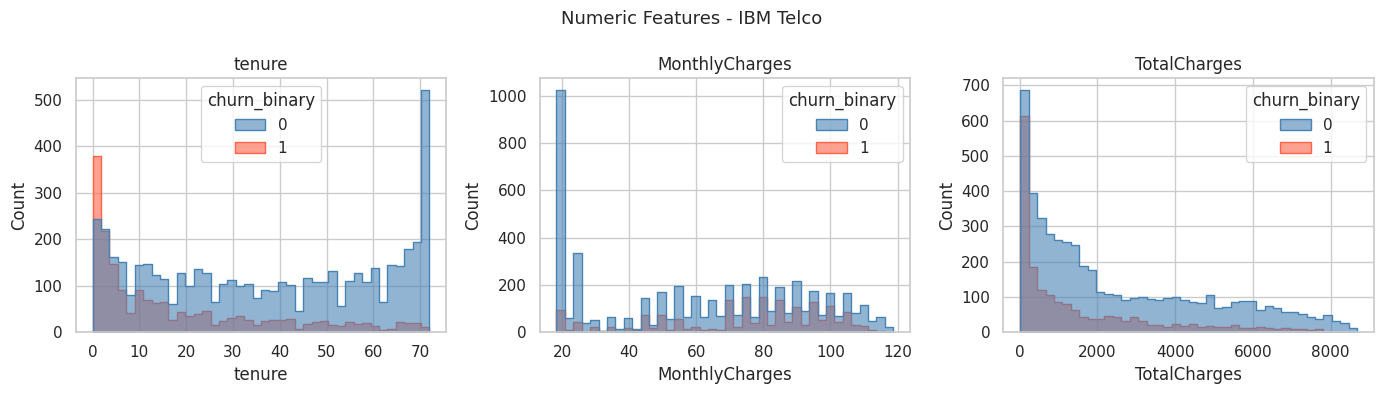

In [ ]:
# IBM Telco numeric distributions
df_ibm_eda['TotalCharges'] = pd.to_numeric(df_ibm_eda['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df_ibm_eda, x=col, hue='churn_binary', bins=40,
                 palette=['steelblue', 'tomato'], alpha=0.6,
                 element='step', ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('Numeric Features - IBM Telco', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'num_dist_ibm.png', bbox_inches='tight')
plt.show()

In [ ]:
# Dataset summary table
# Summary comparison table of the two main datasets
summary = pd.DataFrame({
    'Dataset': ['Customer Churn 1M', 'IBM Telco'],
    'Records': [df_1m_eda.shape[0], df_ibm_eda.shape[0]],
    'Features': [df_1m_eda.shape[1], df_ibm_eda.shape[1]],
    'Churn Rate (%)': [
        round(df_1m_eda['churn'].mean() * 100, 2),
        round(df_ibm_eda['churn_binary'].mean() * 100, 2)
    ],
    'Role': ['Primary Training (Exp2)', 'Train+Test (Exp1) / Test (Exp2)']
})
print(summary.to_string(index=False))

          Dataset  Records  Features  Churn Rate (%)                            Role
Customer Churn 1M  1000000        32            9.92         Primary Training (Exp2)
        IBM Telco     7043        22           26.54 Train+Test (Exp1) / Test (Exp2)


Preprocessing

In [ ]:
# FT-Transformer class definition
class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=192, n_heads=8,
                 n_blocks=3, ffn_dim=256, dropout=0.1):
        super().__init__()
        # Feature Tokenizer: maps each scalar feature → d_token embedding
        self.tokenizer = nn.Linear(1, d_token)
        # Transformer Encoder: 3 blocks of multi-head self-attention
        # norm_first=True = PreNorm variant (same as original paper)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads,
            dim_feedforward=ffn_dim, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)
        self.norm = nn.LayerNorm(d_token)
        # Classification head: d_token → 2 classes (No Churn / Churn)
        self.head = nn.Linear(d_token, 2)

    def forward(self, x):
        x = x.unsqueeze(-1)          # (batch, features) → (batch, features, 1)
        x = self.tokenizer(x)        # (batch, features, 1) → (batch, features, d_token)
        x = self.transformer(x)      # self-attention across all feature tokens
        x = self.norm(x.mean(dim=1)) # mean pooling → (batch, d_token)
        return self.head(x)          # → (batch, 2)

In [ ]:
# Load and clean IBM Telco
# Used as: Exp1 train+test | Exp2 test only
df_ibm = pd.read_csv(PATH_IBM, low_memory=False)

# Step 1: Drop irrelevant columns
df_ibm.drop(columns=['customerID'], inplace=True)

# Step 2: Fix TotalCharges type
df_ibm['TotalCharges'] = pd.to_numeric(df_ibm['TotalCharges'], errors='coerce')

# Step 3: Target encoding (Yes→1, No→0)
df_ibm['churn'] = (df_ibm['Churn'] == 'Yes').astype(int)
df_ibm.drop(columns=['Churn'], inplace=True)

# Step 4: Unify binary service columns (Yes→1, No/No internet service→0)
binary_map = {'Yes': 1, 'No': 0,
              'No internet service': 0,
              'No phone service': 0}

cols_to_binary = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'PhoneService', 'MultipleLines', 'Partner']
for col in cols_to_binary:
    df_ibm[col] = df_ibm[col].map(binary_map)

# InternetService: DSL/Fiber optic→1, No→0
df_ibm['InternetService'] = df_ibm['InternetService'].map(
    {'DSL': 1, 'Fiber optic': 1, 'No': 0})

# Dependents: Yes→1, No→0
df_ibm['Dependents'] = df_ibm['Dependents'].map({'Yes': 1, 'No': 0})

# Step 5: Rename IBM columns to match 1M column names
df_ibm.rename(columns={
    'tenure':           'tenure',
    'MonthlyCharges':   'monthlycharges',
    'TotalCharges':     'totalcharges',
    'Contract':         'contract',
    'PaymentMethod':    'payment_method',
    'PaperlessBilling': 'paperless_billing',
    'PhoneService':     'has_phone_service',
    'InternetService':  'has_internet_service',
    'OnlineSecurity':   'has_online_security',
    'OnlineBackup':     'has_online_backup',
    'DeviceProtection': 'has_device_protection',
    'TechSupport':      'has_tech_support',
    'StreamingTV':      'has_streaming_tv',
    'StreamingMovies':  'has_streaming_movies',
    'gender':           'gender',
    'SeniorCitizen':    'senior_citizen',
    'Dependents':       'dependents',
    'Partner':          'partner',
    'MultipleLines':    'multiple_lines',
}, inplace=True)

print('IBM Telco cleaned shape:', df_ibm.shape)
print('Churn rate:', round(df_ibm['churn'].mean()*100, 2), '%')
print('Missing values:')
print(df_ibm.isnull().sum()[df_ibm.isnull().sum() > 0])
print(df_ibm.head(2))

IBM Telco cleaned shape: (7043, 20)
Churn rate: 26.54 %
Missing values:
totalcharges    11
dtype: int64
   gender  senior_citizen  partner  dependents  tenure  has_phone_service  \
0  Female               0        1           0       1                  0   
1    Male               0        0           0      34                  1   

   multiple_lines  has_internet_service  has_online_security  \
0               0                     1                    0   
1               0                     1                    1   

   has_online_backup  has_device_protection  has_tech_support  \
0                  1                      0                 0   
1                  0                      1                 0   

   has_streaming_tv  has_streaming_movies        contract paperless_billing  \
0                 0                     0  Month-to-month               Yes   
1                 0                     0        One year                No   

     payment_method  monthlycharges  

In [ ]:
 # Load and clean 1M dataset
 # Used as: Exp2 training only
df_1m = pd.read_csv(PATH_1M, low_memory=False)

# Step 1: Drop irrelevant columns
df_1m.drop(columns=['customer_id', 'signup_date'], inplace=True)

# Step 2: Target encoding (already binary integer)
df_1m['churn'] = df_1m['churn'].astype(int)

# Step 3: Unify dependents (0→0, >0→1) to match IBM binary
df_1m['dependents'] = (df_1m['dependents'] > 0).astype(int)

print('1M Dataset shape:', df_1m.shape)
print('Churn rate:', round(df_1m['churn'].mean()*100, 2), '%')
print('Missing values:')
print(df_1m.isnull().sum()[df_1m.isnull().sum() > 0])

1M Dataset shape: (1000000, 30)
Churn rate: 9.92 %
Missing values:
annual_income            29959
customer_satisfaction    19921
num_complaints           29906
avg_monthly_gb           50012
credit_score             40395
dtype: int64


In [ ]:
# Define common features for Experiment 2
COMMON_FEATURES = [
    'tenure', 'monthlycharges', 'totalcharges',
    'contract', 'payment_method', 'paperless_billing',
    'has_phone_service', 'has_internet_service',
    'has_online_security', 'has_online_backup',
    'has_device_protection', 'has_tech_support',
    'has_streaming_tv', 'has_streaming_movies',
    'gender', 'senior_citizen', 'dependents'
]

print('Common features:', len(COMMON_FEATURES))

# Verify all exist in both datasets
all_ok = True
for f in COMMON_FEATURES:
    in_1m  = f in df_1m.columns
    in_ibm = f in df_ibm.columns
    if not in_1m or not in_ibm:
        print(f'MISSING: {f} | 1M:{in_1m} | IBM:{in_ibm}')
        all_ok = False
if all_ok:
    print('All common features verified in both datasets.')

Common features: 17
All common features verified in both datasets.


Experiment 1 preprocessing - IBM Telco dataset

In [ ]:
# IBM Telco: 80% train, 20% test
# Use all IBM Telco features
ibm_features = [c for c in df_ibm.columns if c != 'churn']
X_ibm = df_ibm[ibm_features].copy()
y_ibm = df_ibm['churn'].copy()

# 80/20 stratified split
X_e1_tr, X_e1_te, y_e1_tr, y_e1_te = train_test_split(
    X_ibm, y_ibm,
    test_size=0.2, random_state=42, stratify=y_ibm
)
print('Exp1 Train:', X_e1_tr.shape, '| Churn rate:', round(y_e1_tr.mean()*100, 2), '%')
print('Exp1 Test: ', X_e1_te.shape, '| Churn rate:', round(y_e1_te.mean()*100, 2), '%')

Exp1 Train: (5634, 19) | Churn rate: 26.54 %
Exp1 Test:  (1409, 19) | Churn rate: 26.54 %


In [ ]:
# Fix missing values in IBM Telco
num_cols_e1 = X_e1_tr.select_dtypes(include=np.number).columns.tolist()
cat_cols_e1 = X_e1_tr.select_dtypes(include='object').columns.tolist()

print('Numeric cols:', num_cols_e1)
print('Categorical cols:', cat_cols_e1)

# Median imputation (fit on train only)
num_imp_e1 = SimpleImputer(strategy='median')
X_e1_tr[num_cols_e1] = num_imp_e1.fit_transform(X_e1_tr[num_cols_e1])
X_e1_te[num_cols_e1] = num_imp_e1.transform(X_e1_te[num_cols_e1])

# Most frequent for categorical
cat_imp_e1 = SimpleImputer(strategy='most_frequent')
if cat_cols_e1:
    X_e1_tr[cat_cols_e1] = cat_imp_e1.fit_transform(X_e1_tr[cat_cols_e1])
    X_e1_te[cat_cols_e1] = cat_imp_e1.transform(X_e1_te[cat_cols_e1])

print('Missing in train:', X_e1_tr.isnull().sum().sum())
print('Missing in test: ', X_e1_te.isnull().sum().sum())

Numeric cols: ['senior_citizen', 'partner', 'dependents', 'tenure', 'has_phone_service', 'multiple_lines', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'monthlycharges', 'totalcharges']
Categorical cols: ['gender', 'contract', 'paperless_billing', 'payment_method']
Missing in train: 0
Missing in test:  0


In [ ]:
# Encode IBM Telco categorical columns
# Encode all text columns to numbers
encoders_e1 = {}
for col in cat_cols_e1:
    le = LabelEncoder()
    X_e1_tr[col] = le.fit_transform(X_e1_tr[col].astype(str))
    X_e1_te[col] = le.transform(X_e1_te[col].astype(str))
    encoders_e1[col] = le

print('Encoding done. Shape:', X_e1_tr.shape)

Encoding done. Shape: (5634, 19)


In [ ]:
# SMOTE-ENN
print('Before SMOTE-ENN:', dict(y_e1_tr.value_counts()))

smote_e1 = SMOTEENN(random_state=42)
X_e1_tr_res, y_e1_tr_res = smote_e1.fit_resample(X_e1_tr, y_e1_tr)
y_e1_tr_res = pd.Series(y_e1_tr_res, name='churn')

print('After SMOTE-ENN: ', dict(y_e1_tr_res.value_counts()))
print('Resampled shape: ', X_e1_tr_res.shape)

Before SMOTE-ENN: {0: np.int64(4139), 1: np.int64(1495)}
After SMOTE-ENN:  {1: np.int64(2510), 0: np.int64(2151)}
Resampled shape:  (4661, 19)


In [ ]:
# Feature selection
rf_e1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_e1.fit(X_e1_tr_res, y_e1_tr_res)

sel_e1 = SelectFromModel(rf_e1, prefit=True, threshold='mean')
selected_e1 = X_e1_tr.columns[sel_e1.get_support()].tolist()
print(f'Selected features: {len(selected_e1)} / {X_e1_tr.shape[1]}')
print(selected_e1)

X_e1_tr_sel = pd.DataFrame(
    sel_e1.transform(X_e1_tr_res), columns=selected_e1)
X_e1_te_sel = pd.DataFrame(
    sel_e1.transform(X_e1_te), columns=selected_e1)

Selected features: 5 / 19
['tenure', 'has_internet_service', 'contract', 'monthlycharges', 'totalcharges']


In [ ]:
# Scaling
scaler_e1 = StandardScaler()
X_e1_tr_scaled = pd.DataFrame(
    scaler_e1.fit_transform(X_e1_tr_sel), columns=selected_e1)
X_e1_te_scaled = pd.DataFrame(
    scaler_e1.transform(X_e1_te_sel), columns=selected_e1)

y_e1_te = y_e1_te.reset_index(drop=True)

print('Exp1 Train scaled:', X_e1_tr_scaled.shape)
print('Exp1 Test scaled: ', X_e1_te_scaled.shape)
print('Train churn rate: ', round(y_e1_tr_res.mean()*100, 2), '%')
print('Test churn rate:  ', round(y_e1_te.mean()*100, 2), '%')

Exp1 Train scaled: (4661, 5)
Exp1 Test scaled:  (1409, 5)
Train churn rate:  53.85 %
Test churn rate:   26.54 %


Experiment 2 preprocessing - 1M train

Train on 1M → Test on IBM Telco (cross-dataset)

In [ ]:
# Sample 100k from 1M dataset and split 80% train / 20% validation
X_1m_common = df_1m[COMMON_FEATURES].copy()
y_1m_common = df_1m['churn'].copy()
X_1m_s, _, y_1m_s, _ = train_test_split(
  X_1m_common, y_1m_common,
  train_size=100000, random_state=42, stratify=y_1m_common
)

# 80% train / 20% internal validation (for early stopping only)
X_e2_tr, X_e2_val, y_e2_tr, y_e2_val = train_test_split(
  X_1m_s, y_1m_s,
  test_size=0.2, random_state=42, stratify=y_1m_s
)

print('Exp2 1M Train:', X_e2_tr.shape, '| Churn rate:', round(y_e2_tr.mean()*100, 2), '%')
print('Exp2 1M Val: ', X_e2_val.shape, '| Churn rate:', round(y_e2_val.mean()*100, 2), '%')

Exp2 1M Train: (80000, 17) | Churn rate: 9.92 %
Exp2 1M Val:  (20000, 17) | Churn rate: 9.93 %


In [ ]:
# Fix missing values in 1M dataset
num_cols_e2 = X_e2_tr.select_dtypes(include=np.number).columns.tolist()
cat_cols_e2 = X_e2_tr.select_dtypes(include='object').columns.tolist()

print('Numeric cols:', num_cols_e2)
print('Categorical cols:', cat_cols_e2)

num_imp_e2 = SimpleImputer(strategy='median')
X_e2_tr[num_cols_e2]  = num_imp_e2.fit_transform(X_e2_tr[num_cols_e2])
X_e2_val[num_cols_e2] = num_imp_e2.transform(X_e2_val[num_cols_e2])

cat_imp_e2 = SimpleImputer(strategy='most_frequent')
if cat_cols_e2:
    X_e2_tr[cat_cols_e2]  = cat_imp_e2.fit_transform(X_e2_tr[cat_cols_e2])
    X_e2_val[cat_cols_e2] = cat_imp_e2.transform(X_e2_val[cat_cols_e2])

print('Missing in train:', X_e2_tr.isnull().sum().sum())
print('Missing in val:  ', X_e2_val.isnull().sum().sum())

Numeric cols: ['tenure', 'monthlycharges', 'totalcharges', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'senior_citizen', 'dependents']
Categorical cols: ['contract', 'payment_method', 'paperless_billing', 'gender']
Missing in train: 0
Missing in val:   0


In [ ]:
# Encode 1M dataset categorical columns
# Encode all text columns to numbers
encoders_e2 = {}
for col in cat_cols_e2:
    le = LabelEncoder()
    X_e2_tr[col]  = le.fit_transform(X_e2_tr[col].astype(str))
    X_e2_val[col] = le.transform(X_e2_val[col].astype(str))
    encoders_e2[col] = le

print('Encoding done. Shape:', X_e2_tr.shape)

Encoding done. Shape: (80000, 17)


In [ ]:
# SMOTE-ENN on 1M dataset
print('Before SMOTE-ENN:', dict(y_e2_tr.value_counts()))

smote_e2 = SMOTEENN(random_state=42)
X_e2_tr_res, y_e2_tr_res = smote_e2.fit_resample(X_e2_tr, y_e2_tr)
y_e2_tr_res = pd.Series(y_e2_tr_res, name='churn')

print('After SMOTE-ENN: ', dict(y_e2_tr_res.value_counts()))
print('Resampled shape: ', X_e2_tr_res.shape)

Before SMOTE-ENN: {0: np.int64(72062), 1: np.int64(7938)}
After SMOTE-ENN:  {1: np.int64(63302), 0: np.int64(33734)}
Resampled shape:  (97036, 17)


In [ ]:
# Feature selection
rf_e2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_e2.fit(X_e2_tr_res, y_e2_tr_res)

sel_e2 = SelectFromModel(rf_e2, prefit=True, threshold='mean')
selected_e2 = X_e2_tr.columns[sel_e2.get_support()].tolist()
print(f'Selected features: {len(selected_e2)} / {X_e2_tr.shape[1]}')
print(selected_e2)

X_e2_tr_sel  = pd.DataFrame(sel_e2.transform(X_e2_tr_res),  columns=selected_e2)
X_e2_val_sel = pd.DataFrame(sel_e2.transform(X_e2_val),     columns=selected_e2)

Selected features: 7 / 17
['tenure', 'monthlycharges', 'totalcharges', 'contract', 'has_online_security', 'has_tech_support', 'has_streaming_tv']


In [ ]:
# Scaling + apply to IBM Telco test
scaler_e2 = StandardScaler()
X_e2_tr_scaled  = pd.DataFrame(
    scaler_e2.fit_transform(X_e2_tr_sel), columns=selected_e2)
X_e2_val_scaled = pd.DataFrame(
    scaler_e2.transform(X_e2_val_sel), columns=selected_e2)

# Prepare IBM Telco as test set for Experiment 2
X_ibm_e2 = df_ibm[COMMON_FEATURES].copy()
y_ibm_e2 = df_ibm['churn'].reset_index(drop=True)

# Step 1: Standardise categorical values FIRST before anything else
X_ibm_e2['contract'] = X_ibm_e2['contract'].map({
    'Month-to-month': 'month_to_month',
    'One year':        'one_year',
    'Two year':        'two_year'
})
X_ibm_e2['payment_method'] = X_ibm_e2['payment_method'].map({
    'Electronic check':          'electronic_check',
    'Mailed check':              'mailed_check',
    'Bank transfer (automatic)': 'bank_transfer',
    'Credit card (automatic)':   'credit_card'
})
X_ibm_e2['gender'] = X_ibm_e2['gender'].str.capitalize()

print('After mapping:')
print('contract:', X_ibm_e2['contract'].unique())
print('payment_method:', X_ibm_e2['payment_method'].unique())
print('paperless_billing:', X_ibm_e2['paperless_billing'].unique())
print('gender:', X_ibm_e2['gender'].unique())

# Step 2: Identify numeric and categorical columns
ibm_num_cols = [c for c in num_cols_e2 if c in X_ibm_e2.columns]
ibm_cat_cols = [c for c in cat_cols_e2 if c in X_ibm_e2.columns]

# Step 3: Impute using training-derived imputer
X_ibm_e2[ibm_num_cols] = num_imp_e2.transform(X_ibm_e2[ibm_num_cols])
if ibm_cat_cols:
    X_ibm_e2[ibm_cat_cols] = cat_imp_e2.transform(X_ibm_e2[ibm_cat_cols])

# Step 4: Encode using training-derived encoders
for col in ibm_cat_cols:
    X_ibm_e2[col] = encoders_e2[col].transform(X_ibm_e2[col].astype(str))

# Step 5: Apply feature selection mask
X_ibm_e2_sel = pd.DataFrame(
    sel_e2.transform(X_ibm_e2), columns=selected_e2)

# Step 6: Apply scaler
X_ibm_e2_scaled = pd.DataFrame(
    scaler_e2.transform(X_ibm_e2_sel), columns=selected_e2)

print('Exp2 1M Train scaled: ', X_e2_tr_scaled.shape)
print('Exp2 1M Val scaled:   ', X_e2_val_scaled.shape)
print('Exp2 IBM Test scaled: ', X_ibm_e2_scaled.shape)
print('Exp2 IBM Churn rate:  ', round(y_ibm_e2.mean()*100, 2), '%')

After mapping:
contract: ['month_to_month' 'one_year' 'two_year']
payment_method: ['electronic_check' 'mailed_check' 'bank_transfer' 'credit_card']
paperless_billing: ['Yes' 'No']
gender: ['Female' 'Male']
Exp2 1M Train scaled:  (97036, 7)
Exp2 1M Val scaled:    (20000, 7)
Exp2 IBM Test scaled:  (7043, 7)
Exp2 IBM Churn rate:   26.54 %


In [ ]:
# Rsults Collector
all_results = []

CatBoost

In [ ]:
# Experiment 1 (IBM Telco 80/20)
cb_e1 = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    l2_leaf_reg=3, eval_metric='AUC',
    early_stopping_rounds=30, random_seed=42, verbose=50
)
cb_e1.fit(
    X_e1_tr_scaled, y_e1_tr_res,
    eval_set=(X_e1_te_scaled, y_e1_te)
)

yp_cb_e1  = cb_e1.predict(X_e1_te_scaled)
ypr_cb_e1 = cb_e1.predict_proba(X_e1_te_scaled)[:, 1]

print('\n=== CatBoost — Exp1: IBM Telco 80/20 ===')
print('Accuracy :', round(accuracy_score(y_e1_te, yp_cb_e1), 4))
print('Precision:', round(precision_score(y_e1_te, yp_cb_e1, zero_division=0), 4))
print('Recall   :', round(recall_score(y_e1_te, yp_cb_e1), 4))
print('F1-Score :', round(f1_score(y_e1_te, yp_cb_e1, zero_division=0), 4))
print('AUC-ROC  :', round(roc_auc_score(y_e1_te, ypr_cb_e1), 4))
print()
print(classification_report(y_e1_te, yp_cb_e1, target_names=['No Churn', 'Churn']))

all_results.append({
    'Model':     'CatBoost',
    'Dataset':   'Exp1: IBM Telco 80/20',
    'Accuracy':  round(accuracy_score(y_e1_te, yp_cb_e1), 4),
    'Precision': round(precision_score(y_e1_te, yp_cb_e1, zero_division=0), 4),
    'Recall':    round(recall_score(y_e1_te, yp_cb_e1), 4),
    'F1-Score':  round(f1_score(y_e1_te, yp_cb_e1, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(y_e1_te, ypr_cb_e1), 4)
})

0:	test: 0.8162688	best: 0.8162688 (0)	total: 48.8ms	remaining: 24.3s
50:	test: 0.8381810	best: 0.8389496 (33)	total: 221ms	remaining: 1.95s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.8389495983
bestIteration = 33

Shrink model to first 34 iterations.

=== CatBoost — Exp1: IBM Telco 80/20 ===
Accuracy : 0.7182
Precision: 0.482
Recall   : 0.8235
F1-Score : 0.6081
AUC-ROC  : 0.8389

              precision    recall  f1-score   support

    No Churn       0.91      0.68      0.78      1035
       Churn       0.48      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.72      0.73      1409



In [ ]:
# Experiment 2 (1M Train → IBM Telco Test)
cb_e2 = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    l2_leaf_reg=3, eval_metric='AUC',
    early_stopping_rounds=30, random_seed=42, verbose=50
)
cb_e2.fit(
    X_e2_tr_scaled, y_e2_tr_res,
    eval_set=(X_e2_val_scaled, y_e2_val)
)

yp_cb_e2  = cb_e2.predict(X_ibm_e2_scaled)
ypr_cb_e2 = cb_e2.predict_proba(X_ibm_e2_scaled)[:, 1]

print('\n=== CatBoost — Exp2: 1M→IBM Telco ===')
print('Accuracy :', round(accuracy_score(y_ibm_e2, yp_cb_e2), 4))
print('Precision:', round(precision_score(y_ibm_e2, yp_cb_e2, zero_division=0), 4))
print('Recall   :', round(recall_score(y_ibm_e2, yp_cb_e2), 4))
print('F1-Score :', round(f1_score(y_ibm_e2, yp_cb_e2, zero_division=0), 4))
print('AUC-ROC  :', round(roc_auc_score(y_ibm_e2, ypr_cb_e2), 4))
print()
print(classification_report(y_ibm_e2, yp_cb_e2, target_names=['No Churn', 'Churn']))

all_results.append({
    'Model':     'CatBoost',
    'Dataset':   'Exp2: 1M→IBM Telco',
    'Accuracy':  round(accuracy_score(y_ibm_e2, yp_cb_e2), 4),
    'Precision': round(precision_score(y_ibm_e2, yp_cb_e2, zero_division=0), 4),
    'Recall':    round(recall_score(y_ibm_e2, yp_cb_e2), 4),
    'F1-Score':  round(f1_score(y_ibm_e2, yp_cb_e2, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(y_ibm_e2, ypr_cb_e2), 4)
})

0:	test: 0.6231143	best: 0.6231143 (0)	total: 41ms	remaining: 20.5s
50:	test: 0.6361665	best: 0.6368825 (21)	total: 1.78s	remaining: 15.7s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.6368824608
bestIteration = 21

Shrink model to first 22 iterations.

=== CatBoost — Exp2: 1M→IBM Telco ===
Accuracy : 0.5968
Precision: 0.3872
Recall   : 0.8914
F1-Score : 0.5399
AUC-ROC  : 0.7822

              precision    recall  f1-score   support

    No Churn       0.93      0.49      0.64      5174
       Churn       0.39      0.89      0.54      1869

    accuracy                           0.60      7043
   macro avg       0.66      0.69      0.59      7043
weighted avg       0.78      0.60      0.61      7043



TabNet

In [ ]:
# Experiment 1 (IBM Telco 80/20)
tab_e1 = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, gamma=1.3,
    n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-2, 'weight_decay': 1e-5},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 10, 'gamma': 0.9},
    mask_type='sparsemax', seed=42, verbose=10
)
tab_e1.fit(
    X_e1_tr_scaled.values.astype('float32'), y_e1_tr_res.values,
    eval_set=[(X_e1_te_scaled.values.astype('float32'), y_e1_te.values)],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=100, patience=20,
    batch_size=1024, virtual_batch_size=128
)

yp_tab_e1  = tab_e1.predict(X_e1_te_scaled.values.astype('float32'))
ypr_tab_e1 = tab_e1.predict_proba(X_e1_te_scaled.values.astype('float32'))[:, 1]

print('\n=== TabNet — Exp1: IBM Telco 80/20 ===')
print('Accuracy :', round(accuracy_score(y_e1_te, yp_tab_e1), 4))
print('Precision:', round(precision_score(y_e1_te, yp_tab_e1, zero_division=0), 4))
print('Recall   :', round(recall_score(y_e1_te, yp_tab_e1), 4))
print('F1-Score :', round(f1_score(y_e1_te, yp_tab_e1, zero_division=0), 4))
print('AUC-ROC  :', round(roc_auc_score(y_e1_te, ypr_tab_e1), 4))
print()
print(classification_report(y_e1_te, yp_tab_e1, target_names=['No Churn', 'Churn']))

all_results.append({
    'Model':     'TabNet',
    'Dataset':   'Exp1: IBM Telco 80/20',
    'Accuracy':  round(accuracy_score(y_e1_te, yp_tab_e1), 4),
    'Precision': round(precision_score(y_e1_te, yp_tab_e1, zero_division=0), 4),
    'Recall':    round(recall_score(y_e1_te, yp_tab_e1), 4),
    'F1-Score':  round(f1_score(y_e1_te, yp_tab_e1, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(y_e1_te, ypr_tab_e1), 4)
})

epoch 0  | loss: 0.48193 | test_auc: 0.81164 |  0:00:01s
epoch 10 | loss: 0.20874 | test_auc: 0.8366  |  0:00:04s
epoch 20 | loss: 0.20135 | test_auc: 0.8334  |  0:00:08s
epoch 30 | loss: 0.19681 | test_auc: 0.83626 |  0:00:11s
epoch 40 | loss: 0.2003  | test_auc: 0.83287 |  0:00:14s

Early stopping occurred at epoch 44 with best_epoch = 24 and best_test_auc = 0.83716

=== TabNet — Exp1: IBM Telco 80/20 ===
Accuracy : 0.7147
Precision: 0.4787
Recall   : 0.8422
F1-Score : 0.6105
AUC-ROC  : 0.8372

              precision    recall  f1-score   support

    No Churn       0.92      0.67      0.77      1035
       Churn       0.48      0.84      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.80      0.71      0.73      1409



In [ ]:
# Experiment 2 (1M Train → IBM Telco Test)
tab_e2 = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, gamma=1.3,
    n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-2, 'weight_decay': 1e-5},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 10, 'gamma': 0.9},
    mask_type='sparsemax', seed=42, verbose=10
)
tab_e2.fit(
    X_e2_tr_scaled.values.astype('float32'), y_e2_tr_res.values,
    eval_set=[(X_e2_val_scaled.values.astype('float32'), y_e2_val.values)],
    eval_name=['val'], eval_metric=['auc'],
    max_epochs=100, patience=20,
    batch_size=1024, virtual_batch_size=128
)

yp_tab_e2  = tab_e2.predict(X_ibm_e2_scaled.values.astype('float32'))
ypr_tab_e2 = tab_e2.predict_proba(X_ibm_e2_scaled.values.astype('float32'))[:, 1]

print('\n=== TabNet — Exp2: 1M→IBM Telco ===')
print('Accuracy :', round(accuracy_score(y_ibm_e2, yp_tab_e2), 4))
print('Precision:', round(precision_score(y_ibm_e2, yp_tab_e2, zero_division=0), 4))
print('Recall   :', round(recall_score(y_ibm_e2, yp_tab_e2), 4))
print('F1-Score :', round(f1_score(y_ibm_e2, yp_tab_e2, zero_division=0), 4))
print('AUC-ROC  :', round(roc_auc_score(y_ibm_e2, ypr_tab_e2), 4))
print()
print(classification_report(y_ibm_e2, yp_tab_e2, target_names=['No Churn', 'Churn']))

all_results.append({
    'Model':     'TabNet',
    'Dataset':   'Exp2: 1M→IBM Telco',
    'Accuracy':  round(accuracy_score(y_ibm_e2, yp_tab_e2), 4),
    'Precision': round(precision_score(y_ibm_e2, yp_tab_e2, zero_division=0), 4),
    'Recall':    round(recall_score(y_ibm_e2, yp_tab_e2), 4),
    'F1-Score':  round(f1_score(y_ibm_e2, yp_tab_e2, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(y_ibm_e2, ypr_tab_e2), 4)
})

epoch 0  | loss: 0.51189 | val_auc: 0.61873 |  0:00:06s
epoch 10 | loss: 0.35509 | val_auc: 0.58469 |  0:01:12s
epoch 20 | loss: 0.34105 | val_auc: 0.58469 |  0:02:17s

Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_auc = 0.61873

=== TabNet — Exp2: 1M→IBM Telco ===
Accuracy : 0.6176
Precision: 0.4029
Recall   : 0.9149
F1-Score : 0.5595
AUC-ROC  : 0.7365

              precision    recall  f1-score   support

    No Churn       0.94      0.51      0.66      5174
       Churn       0.40      0.91      0.56      1869

    accuracy                           0.62      7043
   macro avg       0.67      0.71      0.61      7043
weighted avg       0.80      0.62      0.63      7043



FT-Transformer

In [ ]:
# Experiment 1 (IBM Telco 80/20)
ftt_e1 = FTTransformer(n_features=len(selected_e1)).to(DEVICE)
optimizer_e1 = torch.optim.AdamW(ftt_e1.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_e1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_e1, T_max=50)
criterion_e1 = nn.CrossEntropyLoss()

X_e1_tr_t = torch.FloatTensor(X_e1_tr_scaled.values).to(DEVICE)
y_e1_tr_t = torch.LongTensor(y_e1_tr_res.values).to(DEVICE)
X_e1_te_t = torch.FloatTensor(X_e1_te_scaled.values).to(DEVICE)

loader_e1 = DataLoader(
    TensorDataset(X_e1_tr_t, y_e1_tr_t),
    batch_size=256, shuffle=True
)

best_auc_e1   = 0.0
patience_e1   = 0
best_w_e1     = None
print('Training FT-Transformer Experiment 1...')

for epoch in range(1, 51):
    ftt_e1.train()
    for xb, yb in loader_e1:
        optimizer_e1.zero_grad()
        loss = criterion_e1(ftt_e1(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ftt_e1.parameters(), 1.0)
        optimizer_e1.step()
    scheduler_e1.step()

    ftt_e1.eval()
    with torch.no_grad():
        probs_val = torch.softmax(ftt_e1(X_e1_te_t), dim=1)[:, 1].cpu().numpy()
    auc_val = roc_auc_score(y_e1_te.values, probs_val)

    if epoch % 5 == 0:
        print(f'Epoch {epoch}/50 | Val AUC: {auc_val:.4f}')

    if auc_val > best_auc_e1:
        best_auc_e1 = auc_val
        patience_e1 = 0
        best_w_e1   = {k: v.clone() for k, v in ftt_e1.state_dict().items()}
    else:
        patience_e1 += 1
        if patience_e1 >= 10:
            print(f'Early stopping at epoch {epoch}')
            break

ftt_e1.load_state_dict(best_w_e1)
print(f'Best Val AUC: {best_auc_e1:.4f}')

ftt_e1.eval()
with torch.no_grad():
    ypr_ftt_e1 = torch.softmax(ftt_e1(X_e1_te_t), dim=1)[:, 1].cpu().numpy()
yp_ftt_e1 = (ypr_ftt_e1 >= 0.5).astype(int)

print('\n=== FT-Transformer — Exp1: IBM Telco 80/20 ===')
print('Accuracy :', round(accuracy_score(y_e1_te, yp_ftt_e1), 4))
print('Precision:', round(precision_score(y_e1_te, yp_ftt_e1, zero_division=0), 4))
print('Recall   :', round(recall_score(y_e1_te, yp_ftt_e1), 4))
print('F1-Score :', round(f1_score(y_e1_te, yp_ftt_e1, zero_division=0), 4))
print('AUC-ROC  :', round(roc_auc_score(y_e1_te, ypr_ftt_e1), 4))
print()
print(classification_report(y_e1_te, yp_ftt_e1, target_names=['No Churn', 'Churn']))

all_results.append({
    'Model':     'FT-Transformer',
    'Dataset':   'Exp1: IBM Telco 80/20',
    'Accuracy':  round(accuracy_score(y_e1_te, yp_ftt_e1), 4),
    'Precision': round(precision_score(y_e1_te, yp_ftt_e1, zero_division=0), 4),
    'Recall':    round(recall_score(y_e1_te, yp_ftt_e1), 4),
    'F1-Score':  round(f1_score(y_e1_te, yp_ftt_e1, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(y_e1_te, ypr_ftt_e1), 4)
})

Training FT-Transformer Experiment 1...
Epoch 5/50 | Val AUC: 0.7915
Epoch 10/50 | Val AUC: 0.8097
Epoch 15/50 | Val AUC: 0.8163
Epoch 20/50 | Val AUC: 0.8166
Epoch 25/50 | Val AUC: 0.8153
Epoch 30/50 | Val AUC: 0.8209
Epoch 35/50 | Val AUC: 0.8228
Epoch 40/50 | Val AUC: 0.8231
Epoch 45/50 | Val AUC: 0.8225
Early stopping at epoch 46
Best Val AUC: 0.8261

=== FT-Transformer — Exp1: IBM Telco 80/20 ===
Accuracy : 0.7168
Precision: 0.48
Recall   : 0.8021
F1-Score : 0.6006
AUC-ROC  : 0.8261

              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.78      1035
       Churn       0.48      0.80      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.79      0.72      0.73      1409



In [ ]:
# Experiment 2 (1M Train → IBM Telco Test)
ftt_e2 = FTTransformer(n_features=len(selected_e2)).to(DEVICE)
optimizer_e2 = torch.optim.AdamW(ftt_e2.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_e2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_e2, T_max=50)
criterion_e2 = nn.CrossEntropyLoss()

X_e2_tr_t  = torch.FloatTensor(X_e2_tr_scaled.values).to(DEVICE)
y_e2_tr_t  = torch.LongTensor(y_e2_tr_res.values).to(DEVICE)
X_e2_val_t = torch.FloatTensor(X_e2_val_scaled.values).to(DEVICE)
X_ibm_e2_t = torch.FloatTensor(X_ibm_e2_scaled.values).to(DEVICE)

loader_e2 = DataLoader(
    TensorDataset(X_e2_tr_t, y_e2_tr_t),
    batch_size=256, shuffle=True
)

best_auc_e2 = 0.0
patience_e2 = 0
best_w_e2   = None
print('Training FT-Transformer Experiment 2...')

for epoch in range(1, 51):
    ftt_e2.train()
    for xb, yb in loader_e2:
        optimizer_e2.zero_grad()
        loss = criterion_e2(ftt_e2(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ftt_e2.parameters(), 1.0)
        optimizer_e2.step()
    scheduler_e2.step()

    ftt_e2.eval()
    with torch.no_grad():
        probs_val = torch.softmax(ftt_e2(X_e2_val_t), dim=1)[:, 1].cpu().numpy()
    auc_val = roc_auc_score(y_e2_val.values, probs_val)

    if epoch % 5 == 0:
        print(f'Epoch {epoch}/50 | Val AUC: {auc_val:.4f}')

    if auc_val > best_auc_e2:
        best_auc_e2 = auc_val
        patience_e2 = 0
        best_w_e2   = {k: v.clone() for k, v in ftt_e2.state_dict().items()}
    else:
        patience_e2 += 1
        if patience_e2 >= 10:
            print(f'Early stopping at epoch {epoch}')
            break

ftt_e2.load_state_dict(best_w_e2)
print(f'Best Val AUC: {best_auc_e2:.4f}')

ftt_e2.eval()
with torch.no_grad():
    ypr_ftt_e2 = torch.softmax(ftt_e2(X_ibm_e2_t), dim=1)[:, 1].cpu().numpy()
yp_ftt_e2 = (ypr_ftt_e2 >= 0.5).astype(int)

print('\n=== FT-Transformer — Exp2: 1M→IBM Telco ===')
print('Accuracy :', round(accuracy_score(y_ibm_e2, yp_ftt_e2), 4))
print('Precision:', round(precision_score(y_ibm_e2, yp_ftt_e2, zero_division=0), 4))
print('Recall   :', round(recall_score(y_ibm_e2, yp_ftt_e2), 4))
print('F1-Score :', round(f1_score(y_ibm_e2, yp_ftt_e2, zero_division=0), 4))
print('AUC-ROC  :', round(roc_auc_score(y_ibm_e2, ypr_ftt_e2), 4))
print()
print(classification_report(y_ibm_e2, yp_ftt_e2, target_names=['No Churn', 'Churn']))

all_results.append({
    'Model':     'FT-Transformer',
    'Dataset':   'Exp2: 1M→IBM Telco',
    'Accuracy':  round(accuracy_score(y_ibm_e2, yp_ftt_e2), 4),
    'Precision': round(precision_score(y_ibm_e2, yp_ftt_e2, zero_division=0), 4),
    'Recall':    round(recall_score(y_ibm_e2, yp_ftt_e2), 4),
    'F1-Score':  round(f1_score(y_ibm_e2, yp_ftt_e2, zero_division=0), 4),
    'AUC-ROC':   round(roc_auc_score(y_ibm_e2, ypr_ftt_e2), 4)
})

Training FT-Transformer Experiment 2...
Epoch 5/50 | Val AUC: 0.6248
Epoch 10/50 | Val AUC: 0.6233
Epoch 15/50 | Val AUC: 0.6245
Early stopping at epoch 16
Best Val AUC: 0.6276

=== FT-Transformer — Exp2: 1M→IBM Telco ===
Accuracy : 0.473
Precision: 0.3268
Recall   : 0.9299
F1-Score : 0.4836
AUC-ROC  : 0.6664

              precision    recall  f1-score   support

    No Churn       0.92      0.31      0.46      5174
       Churn       0.33      0.93      0.48      1869

    accuracy                           0.47      7043
   macro avg       0.63      0.62      0.47      7043
weighted avg       0.77      0.47      0.47      7043



Results summary

In [ ]:
# Results summary
results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_PATH + 'all_results.csv', index=False)
print('\n=== FULL RESULTS SUMMARY ===')
print(results_df.to_string(index=False))


=== FULL RESULTS SUMMARY ===
         Model               Dataset  Accuracy  Precision  Recall  F1-Score  AUC-ROC
      CatBoost Exp1: IBM Telco 80/20    0.7182     0.4820  0.8235    0.6081   0.8389
      CatBoost    Exp2: 1M→IBM Telco    0.5968     0.3872  0.8914    0.5399   0.7822
        TabNet Exp1: IBM Telco 80/20    0.7147     0.4787  0.8422    0.6105   0.8372
        TabNet    Exp2: 1M→IBM Telco    0.6176     0.4029  0.9149    0.5595   0.7365
FT-Transformer Exp1: IBM Telco 80/20    0.7168     0.4800  0.8021    0.6006   0.8261
FT-Transformer    Exp2: 1M→IBM Telco    0.4730     0.3268  0.9299    0.4836   0.6664


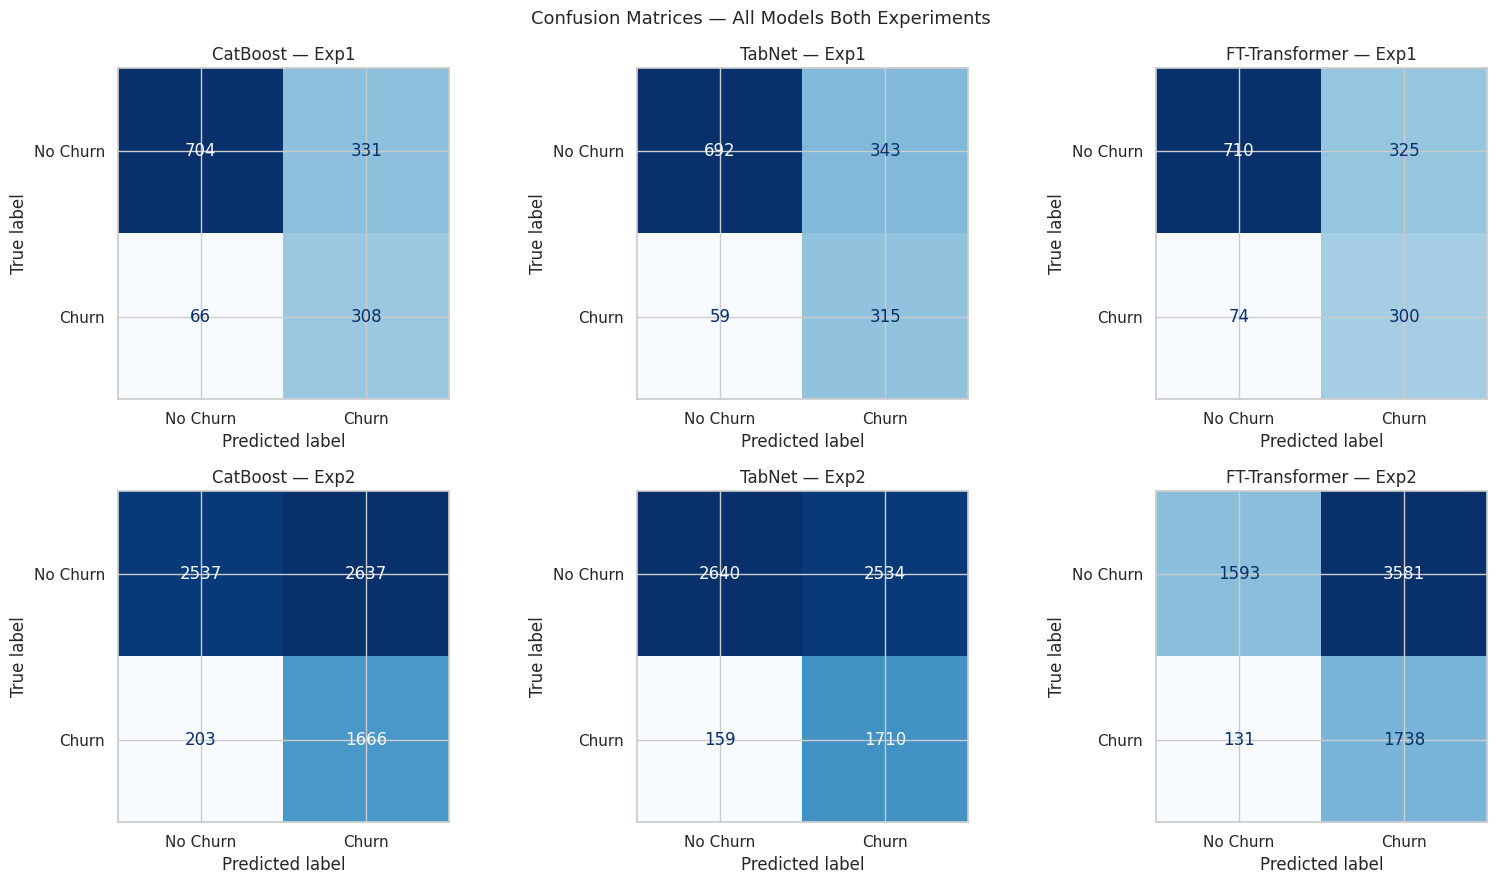

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pairs = [
    (y_e1_te,  yp_cb_e1,  'CatBoost — Exp1'),
    (y_e1_te,  yp_tab_e1, 'TabNet — Exp1'),
    (y_e1_te,  yp_ftt_e1, 'FT-Transformer — Exp1'),
    (y_ibm_e2, yp_cb_e2,  'CatBoost — Exp2'),
    (y_ibm_e2, yp_tab_e2, 'TabNet — Exp2'),
    (y_ibm_e2, yp_ftt_e2, 'FT-Transformer — Exp2'),
]
for ax, (yt, yp, title) in zip(axes.flatten(), pairs):
    cm = confusion_matrix(yt, yp)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.suptitle('Confusion Matrices — All Models Both Experiments', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'confusion_matrices.png', bbox_inches='tight')
plt.show()

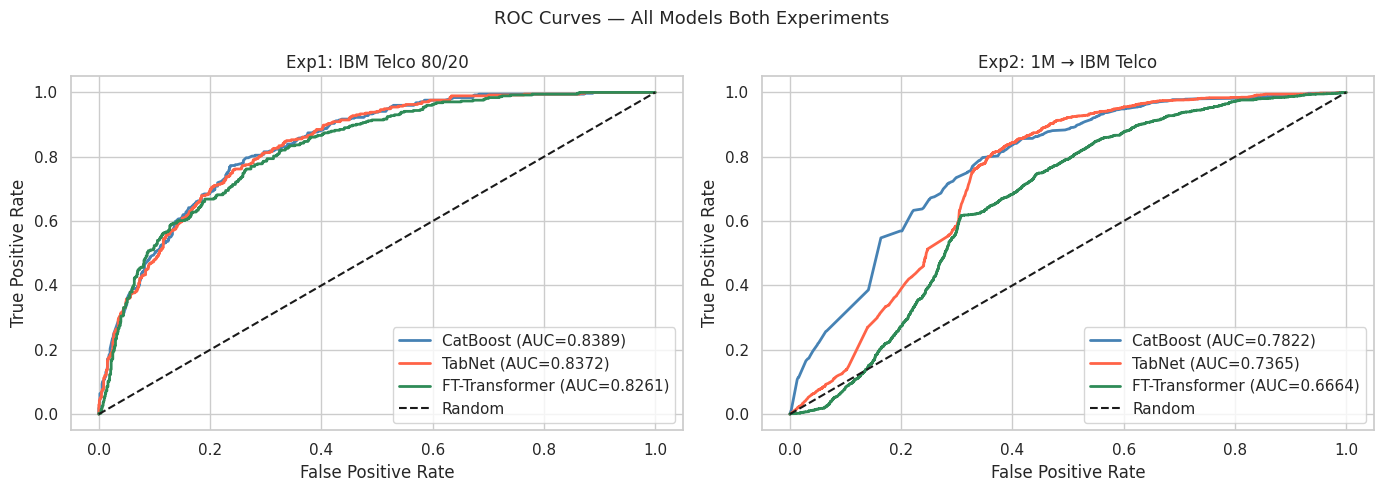

In [ ]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, yt, pairs_roc, title in [
    (axes[0], 'Exp1', y_e1_te,
     [(ypr_cb_e1,'CatBoost','steelblue'),
      (ypr_tab_e1,'TabNet','tomato'),
      (ypr_ftt_e1,'FT-Transformer','seagreen')],
     'Exp1: IBM Telco 80/20'),
    (axes[1], 'Exp2', y_ibm_e2,
     [(ypr_cb_e2,'CatBoost','steelblue'),
      (ypr_tab_e2,'TabNet','tomato'),
      (ypr_ftt_e2,'FT-Transformer','seagreen')],
     'Exp2: 1M → IBM Telco'),
]:
    for ypr, name, color in pairs_roc:
        fpr, tpr, _ = roc_curve(yt, ypr)
        auc = roc_auc_score(yt, ypr)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
                color=color, linewidth=2)
    ax.plot([0,1],[0,1],'k--', label='Random')
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()

plt.suptitle('ROC Curves — All Models Both Experiments', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'roc_curves.png', bbox_inches='tight')
plt.show()

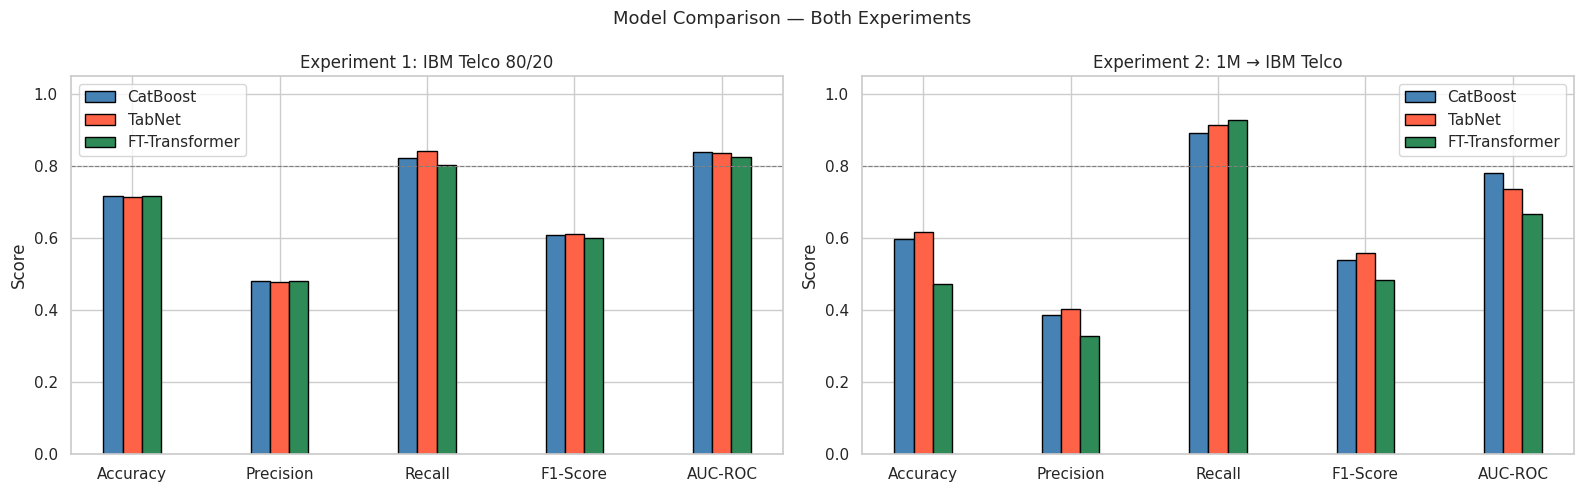

In [ ]:
# Model comparison bar chart
metrics     = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
models_list = ['CatBoost','TabNet','FT-Transformer']
colors      = ['steelblue','tomato','seagreen']
x           = np.arange(len(metrics))
width       = 0.13

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
exp_labels = ['Exp1: IBM Telco 80/20', 'Exp2: 1M→IBM Telco']
titles     = ['Experiment 1: IBM Telco 80/20', 'Experiment 2: 1M → IBM Telco']

for ax, exp, title in zip(axes, exp_labels, titles):
    for i, (model, color) in enumerate(zip(models_list, colors)):
        row  = results_df[(results_df['Model']==model) &
                          (results_df['Dataset']==exp)]
        vals = row[metrics].values.flatten()
        ax.bar(x + i*width, vals, width, label=model,
               color=color, edgecolor='black')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8)
    ax.legend()

plt.suptitle('Model Comparison — Both Experiments', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'model_comparison.png', bbox_inches='tight')
plt.show()

SHAP Experiment 1

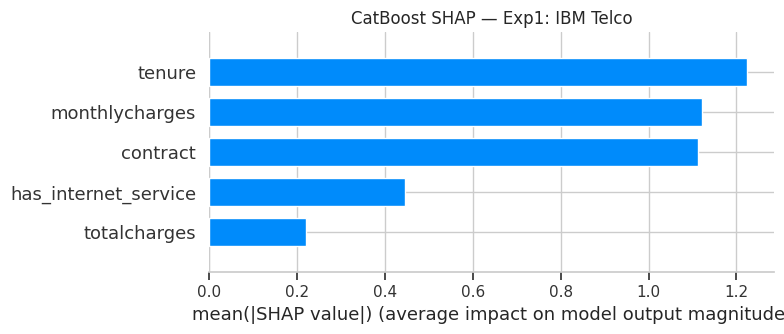

CatBoost SHAP top 10 (Exp1):
                Feature  CatBoost_E1
0                tenure     1.224424
3        monthlycharges     1.122075
2              contract     1.112153
1  has_internet_service     0.446383
4          totalcharges     0.219286


In [ ]:
# SHAP analysis
feature_names_e1 = selected_e1
X_shap_e1    = X_e1_te_scaled.sample(200, random_state=42).reset_index(drop=True)
X_shap_np_e1 = X_shap_e1.values.astype('float32')
X_bg_e1      = X_e1_tr_scaled.sample(50, random_state=42).values.astype('float32')

# CatBoost — TreeExplainer (exact)
explainer_cb_e1 = shap.TreeExplainer(cb_e1)
shap_cb_e1      = explainer_cb_e1.shap_values(X_shap_e1)
if isinstance(shap_cb_e1, list):
    shap_cb_e1 = shap_cb_e1[1]

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_cb_e1, X_shap_e1, feature_names=feature_names_e1,
                  plot_type='bar', show=False, max_display=10)
plt.title('CatBoost SHAP — Exp1: IBM Telco')
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'shap_cb_e1.png', bbox_inches='tight')
plt.show()

mean_shap_cb_e1 = pd.DataFrame({
    'Feature':      feature_names_e1,
    'CatBoost_E1':  np.abs(shap_cb_e1).mean(axis=0)
}).sort_values('CatBoost_E1', ascending=False)
print('CatBoost SHAP top 10 (Exp1):')
print(mean_shap_cb_e1.head(10))

SHAP TabNet + FTT Experiment 1

In [ ]:
# TabNet — KernelExplainer (approximated)
def tab_e1_predict(X):
    return tab_e1.predict_proba(X.astype('float32'))

explainer_tab_e1 = shap.KernelExplainer(tab_e1_predict, X_bg_e1)
shap_tab_e1_raw  = explainer_tab_e1.shap_values(X_shap_np_e1, nsamples=50)
shap_tab_e1 = np.array(shap_tab_e1_raw)
if shap_tab_e1.ndim == 3:
    shap_tab_e1 = shap_tab_e1[:, :, 1]

# FT-Transformer — KernelExplainer (approximated)
def ftt_e1_predict(X):
    ftt_e1.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X).to(DEVICE)
        return torch.softmax(ftt_e1(t), dim=1).cpu().numpy()

explainer_ftt_e1 = shap.KernelExplainer(ftt_e1_predict, X_bg_e1)
shap_ftt_e1_raw  = explainer_ftt_e1.shap_values(X_shap_np_e1, nsamples=50)
shap_ftt_e1 = np.array(shap_ftt_e1_raw)
if shap_ftt_e1.ndim == 3:
    shap_ftt_e1 = shap_ftt_e1[:, :, 1]

mean_shap_tab_e1 = pd.DataFrame({
    'Feature':   feature_names_e1,
    'TabNet_E1': np.abs(shap_tab_e1).mean(axis=0)
}).sort_values('TabNet_E1', ascending=False)

mean_shap_ftt_e1 = pd.DataFrame({
    'Feature': feature_names_e1,
    'FTT_E1':  np.abs(shap_ftt_e1).mean(axis=0)
}).sort_values('FTT_E1', ascending=False)

print('TabNet SHAP top 10 (Exp1):')
print(mean_shap_tab_e1.head(10))
print('\nFT-Transformer SHAP top 10 (Exp1):')
print(mean_shap_ftt_e1.head(10))

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

TabNet SHAP top 10 (Exp1):
                Feature  TabNet_E1
3        monthlycharges   0.189031
4          totalcharges   0.146814
2              contract   0.135313
0                tenure   0.088916
1  has_internet_service   0.036511

FT-Transformer SHAP top 10 (Exp1):
                Feature    FTT_E1
2              contract  0.165481
4          totalcharges  0.093716
1  has_internet_service  0.085407
3        monthlycharges  0.070363
0                tenure  0.059971


SHAP Experiment 2

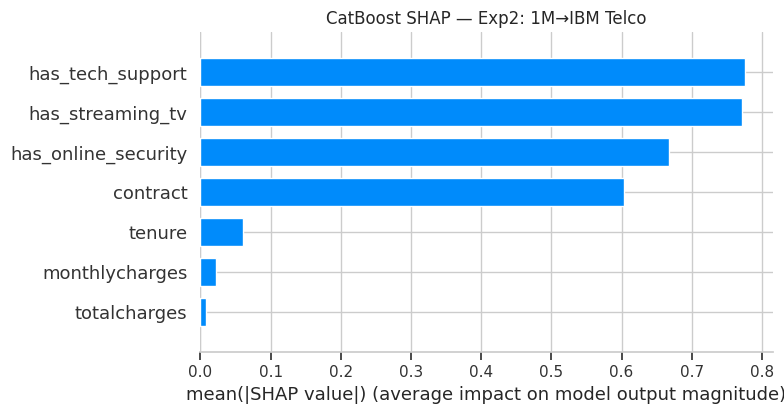

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

CatBoost SHAP top 10 (Exp2):
               Feature  CatBoost_E2
5     has_tech_support     0.776431
6     has_streaming_tv     0.771503
4  has_online_security     0.667052
3             contract     0.603174
0               tenure     0.060017
1       monthlycharges     0.022490
2         totalcharges     0.007672

TabNet SHAP top 10 (Exp2):
               Feature  TabNet_E2
3             contract   0.284795
5     has_tech_support   0.047701
0               tenure   0.038549
4  has_online_security   0.030194
6     has_streaming_tv   0.026623
2         totalcharges   0.026443
1       monthlycharges   0.017797

FT-Transformer SHAP top 10 (Exp2):
               Feature    FTT_E2
3             contract  0.217649
1       monthlycharges  0.079590
4  has_online_security  0.050329
6     has_streaming_tv  0.037999
5     has_tech_support  0.034619
0               tenure  0.023046
2         totalcharges  0.016954


In [ ]:
feature_names_e2 = selected_e2
X_shap_e2    = X_ibm_e2_scaled.sample(200, random_state=42).reset_index(drop=True)
X_shap_np_e2 = X_shap_e2.values.astype('float32')
X_bg_e2      = X_e2_tr_scaled.sample(50, random_state=42).values.astype('float32')

# CatBoost
explainer_cb_e2 = shap.TreeExplainer(cb_e2)
shap_cb_e2      = explainer_cb_e2.shap_values(X_shap_e2)
if isinstance(shap_cb_e2, list):
    shap_cb_e2 = shap_cb_e2[1]

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_cb_e2, X_shap_e2, feature_names=feature_names_e2,
                  plot_type='bar', show=False, max_display=10)
plt.title('CatBoost SHAP — Exp2: 1M→IBM Telco')
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'shap_cb_e2.png', bbox_inches='tight')
plt.show()

# TabNet
def tab_e2_predict(X):
    return tab_e2.predict_proba(X.astype('float32'))

explainer_tab_e2 = shap.KernelExplainer(tab_e2_predict, X_bg_e2)
shap_tab_e2_raw  = explainer_tab_e2.shap_values(X_shap_np_e2, nsamples=50)
shap_tab_e2 = np.array(shap_tab_e2_raw)
if shap_tab_e2.ndim == 3:
    shap_tab_e2 = shap_tab_e2[:, :, 1]

# FT-Transformer
def ftt_e2_predict(X):
    ftt_e2.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X).to(DEVICE)
        return torch.softmax(ftt_e2(t), dim=1).cpu().numpy()

explainer_ftt_e2 = shap.KernelExplainer(ftt_e2_predict, X_bg_e2)
shap_ftt_e2_raw  = explainer_ftt_e2.shap_values(X_shap_np_e2, nsamples=50)
shap_ftt_e2 = np.array(shap_ftt_e2_raw)
if shap_ftt_e2.ndim == 3:
    shap_ftt_e2 = shap_ftt_e2[:, :, 1]

mean_shap_cb_e2  = pd.DataFrame({'Feature': feature_names_e2,
    'CatBoost_E2': np.abs(shap_cb_e2).mean(axis=0)}).sort_values('CatBoost_E2',  ascending=False)
mean_shap_tab_e2 = pd.DataFrame({'Feature': feature_names_e2,
    'TabNet_E2':   np.abs(shap_tab_e2).mean(axis=0)}).sort_values('TabNet_E2',    ascending=False)
mean_shap_ftt_e2 = pd.DataFrame({'Feature': feature_names_e2,
    'FTT_E2':      np.abs(shap_ftt_e2).mean(axis=0)}).sort_values('FTT_E2',       ascending=False)

print('CatBoost SHAP top 10 (Exp2):');       print(mean_shap_cb_e2.head(10))
print('\nTabNet SHAP top 10 (Exp2):');        print(mean_shap_tab_e2.head(10))
print('\nFT-Transformer SHAP top 10 (Exp2):');print(mean_shap_ftt_e2.head(10))

SHAP consistency: Spearman rank correlation

In [ ]:
# SHAP Consistency Analysis
def get_ranks(mean_shap_df, score_col):
    df = mean_shap_df.copy()
    df['rank'] = df[score_col].rank(ascending=False)
    return df.set_index('Feature')['rank']

# Experiment 1
rk_cb_e1  = get_ranks(mean_shap_cb_e1,  'CatBoost_E1')
rk_tab_e1 = get_ranks(mean_shap_tab_e1, 'TabNet_E1')
rk_ftt_e1 = get_ranks(mean_shap_ftt_e1, 'FTT_E1')
idx_e1 = rk_cb_e1.index

sp_cb_tab_e1,  _ = spearmanr(rk_cb_e1[idx_e1],  rk_tab_e1[idx_e1])
sp_cb_ftt_e1,  _ = spearmanr(rk_cb_e1[idx_e1],  rk_ftt_e1[idx_e1])
sp_tab_ftt_e1, _ = spearmanr(rk_tab_e1[idx_e1], rk_ftt_e1[idx_e1])

# Experiment 2
rk_cb_e2  = get_ranks(mean_shap_cb_e2,  'CatBoost_E2')
rk_tab_e2 = get_ranks(mean_shap_tab_e2, 'TabNet_E2')
rk_ftt_e2 = get_ranks(mean_shap_ftt_e2, 'FTT_E2')
idx_e2 = rk_cb_e2.index

sp_cb_tab_e2,  _ = spearmanr(rk_cb_e2[idx_e2],  rk_tab_e2[idx_e2])
sp_cb_ftt_e2,  _ = spearmanr(rk_cb_e2[idx_e2],  rk_ftt_e2[idx_e2])
sp_tab_ftt_e2, _ = spearmanr(rk_tab_e2[idx_e2], rk_ftt_e2[idx_e2])

consistency_df = pd.DataFrame([
    {'Experiment': 'Exp1: IBM Telco 80/20', 'Model Pair': 'CatBoost vs TabNet',         'Spearman r': round(sp_cb_tab_e1,  4)},
    {'Experiment': 'Exp1: IBM Telco 80/20', 'Model Pair': 'CatBoost vs FT-Transformer', 'Spearman r': round(sp_cb_ftt_e1,  4)},
    {'Experiment': 'Exp1: IBM Telco 80/20', 'Model Pair': 'TabNet vs FT-Transformer',   'Spearman r': round(sp_tab_ftt_e1, 4)},
    {'Experiment': 'Exp2: 1M→IBM Telco',   'Model Pair': 'CatBoost vs TabNet',         'Spearman r': round(sp_cb_tab_e2,  4)},
    {'Experiment': 'Exp2: 1M→IBM Telco',   'Model Pair': 'CatBoost vs FT-Transformer', 'Spearman r': round(sp_cb_ftt_e2,  4)},
    {'Experiment': 'Exp2: 1M→IBM Telco',   'Model Pair': 'TabNet vs FT-Transformer',   'Spearman r': round(sp_tab_ftt_e2, 4)},
])
consistency_df.to_csv(OUTPUT_PATH + 'shap_consistency.csv', index=False)
print('\n=== SHAP CONSISTENCY (Spearman Rank Correlation) ===')
print(consistency_df.to_string(index=False))


=== SHAP CONSISTENCY (Spearman Rank Correlation) ===
           Experiment                 Model Pair  Spearman r
Exp1: IBM Telco 80/20         CatBoost vs TabNet      0.0000
Exp1: IBM Telco 80/20 CatBoost vs FT-Transformer     -0.7000
Exp1: IBM Telco 80/20   TabNet vs FT-Transformer      0.1000
   Exp2: 1M→IBM Telco         CatBoost vs TabNet      0.5357
   Exp2: 1M→IBM Telco CatBoost vs FT-Transformer      0.1786
   Exp2: 1M→IBM Telco   TabNet vs FT-Transformer      0.1786


SHAP heatmap comparison

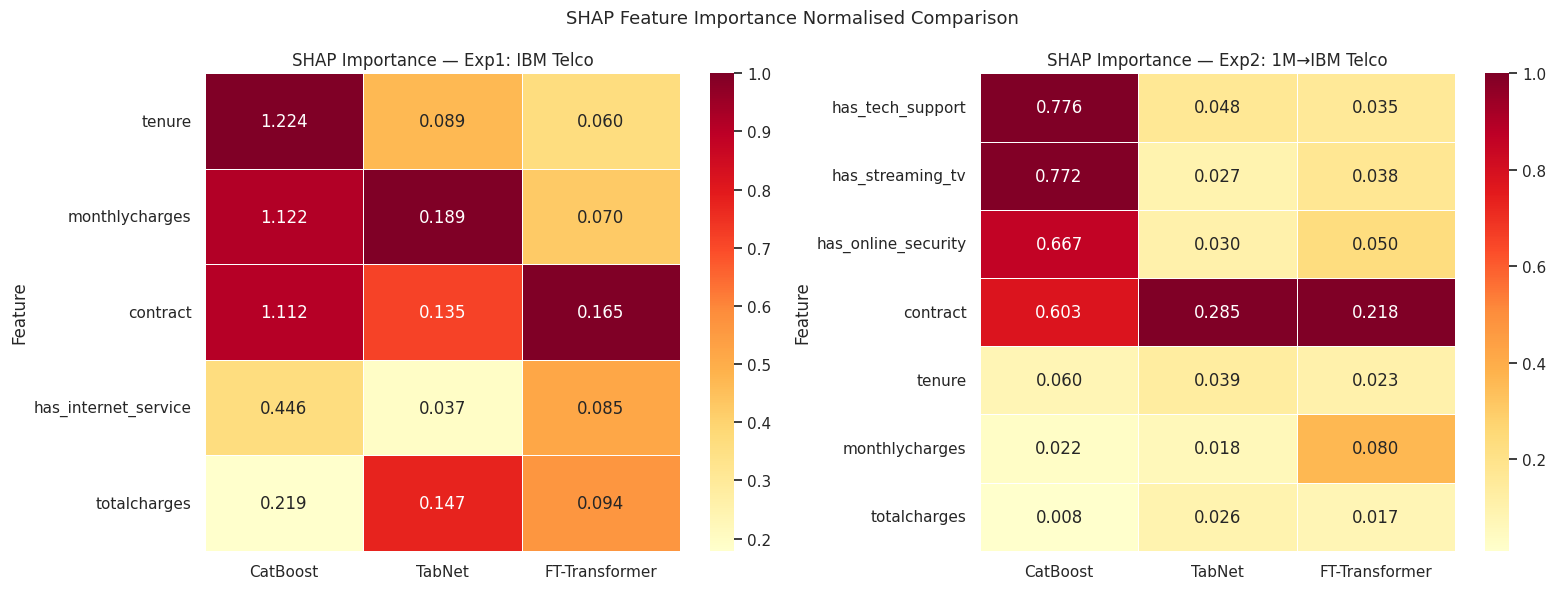

In [ ]:
def make_top10_heatmap(cb_df, tab_df, ftt_df, cb_col, tab_col, ftt_col, title, ax):
    top10 = (cb_df.head(10)
             .merge(tab_df.rename(columns={tab_col: 'TabNet'}),        on='Feature')
             .merge(ftt_df.rename(columns={ftt_col: 'FT-Transformer'}), on='Feature'))
    top10 = top10.set_index('Feature')[[cb_col, 'TabNet', 'FT-Transformer']]
    top10.columns = ['CatBoost', 'TabNet', 'FT-Transformer']
    top10_norm = top10.div(top10.max())
    sns.heatmap(top10_norm, annot=top10.round(3), fmt='.3f',
                cmap='YlOrRd', linewidths=0.5, ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
make_top10_heatmap(mean_shap_cb_e1, mean_shap_tab_e1, mean_shap_ftt_e1,
                   'CatBoost_E1', 'TabNet_E1', 'FTT_E1',
                   'SHAP Importance — Exp1: IBM Telco', axes[0])
make_top10_heatmap(mean_shap_cb_e2, mean_shap_tab_e2, mean_shap_ftt_e2,
                   'CatBoost_E2', 'TabNet_E2', 'FTT_E2',
                   'SHAP Importance — Exp2: 1M→IBM Telco', axes[1])
plt.suptitle('SHAP Feature Importance Normalised Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'shap_heatmap.png', bbox_inches='tight')
plt.show()

AUC comparison Exp1 vs Exp2 + final summary

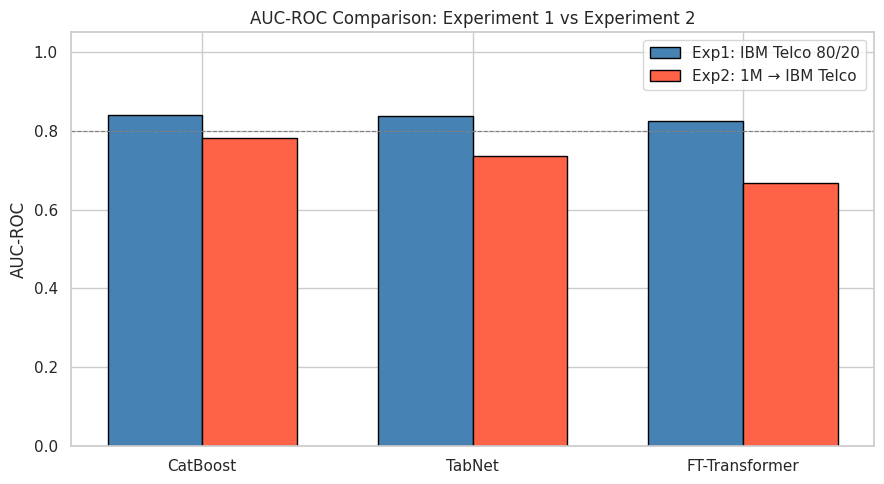


=== FINAL RESULTS SUMMARY ===
         Model               Dataset  Accuracy  Precision  Recall  F1-Score  AUC-ROC
      CatBoost Exp1: IBM Telco 80/20    0.7182     0.4820  0.8235    0.6081   0.8389
      CatBoost    Exp2: 1M→IBM Telco    0.5968     0.3872  0.8914    0.5399   0.7822
        TabNet Exp1: IBM Telco 80/20    0.7147     0.4787  0.8422    0.6105   0.8372
        TabNet    Exp2: 1M→IBM Telco    0.6176     0.4029  0.9149    0.5595   0.7365
FT-Transformer Exp1: IBM Telco 80/20    0.7168     0.4800  0.8021    0.6006   0.8261
FT-Transformer    Exp2: 1M→IBM Telco    0.4730     0.3268  0.9299    0.4836   0.6664

=== SHAP CONSISTENCY ===
           Experiment                 Model Pair  Spearman r
Exp1: IBM Telco 80/20         CatBoost vs TabNet      0.0000
Exp1: IBM Telco 80/20 CatBoost vs FT-Transformer     -0.7000
Exp1: IBM Telco 80/20   TabNet vs FT-Transformer      0.1000
   Exp2: 1M→IBM Telco         CatBoost vs TabNet      0.5357
   Exp2: 1M→IBM Telco CatBoost vs FT-Transf

In [ ]:
# Final Comparison Chart
models_list = ['CatBoost', 'TabNet', 'FT-Transformer']
auc_e1 = [results_df[(results_df['Model']==m) &
           (results_df['Dataset']=='Exp1: IBM Telco 80/20')]['AUC-ROC'].values[0]
           for m in models_list]
auc_e2 = [results_df[(results_df['Model']==m) &
           (results_df['Dataset']=='Exp2: 1M→IBM Telco')]['AUC-ROC'].values[0]
           for m in models_list]

x     = np.arange(len(models_list))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, auc_e1, width, label='Exp1: IBM Telco 80/20',
       color='steelblue', edgecolor='black')
ax.bar(x + width/2, auc_e2, width, label='Exp2: 1M → IBM Telco',
       color='tomato', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylim(0, 1.05)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC Comparison: Experiment 1 vs Experiment 2')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_PATH + 'exp1_vs_exp2_auc.png', bbox_inches='tight')
plt.show()

print('\n=== FINAL RESULTS SUMMARY ===')
print(results_df.to_string(index=False))
print('\n=== SHAP CONSISTENCY ===')
print(consistency_df.to_string(index=False))